# **Análisis de Datos | 190304018-1 | 2026-1** | **Entrega 3** |

**Integrantes - Equipo 8:**
*   Mariana Villegas Ochoa
*   Melisa Colorado Soto
*   Jaider Santiago Villa David
*   Hernán Darío Flórez Martínez
---

# **Dataset: Video Game Sales**
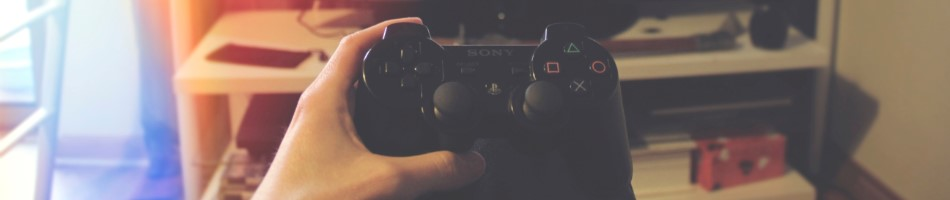

Recuperado de: https://www.kaggle.com/datasets/gregorut/videogamesales

In [ ]:
#Importe desde Kaggle
import kagglehub

#Descargar la versión más actualizada
path = kagglehub.dataset_download("gregorut/videogamesales")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'videogamesales' dataset.
Path to dataset files: /kaggle/input/videogamesales


In [ ]:
#Importación de librerías y carga de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('default')
sns.set_palette("husl")

# Ubicación del dataset
path_dataset = path + "/vgsales.csv"

# Cargar el dataset
df = pd.read_csv(path_dataset)

# Visualización rápida
print("Dimensiones del dataset:", df.shape)
print("\nPrimeras filas:")
print(df.head())

Dimensiones del dataset: (16598, 11)

Primeras filas:
   Rank                      Name Platform    Year         Genre Publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29.08      3.58      6.81         0.77         40.24  
2     15.85     12.88      3.79         3.31         35.82  
3     15.75     11.01      3.28         2.96         33.00  
4     11.27      8.89     10.22         1.00         31.37  


# **Fase 1: Comprensión del problema**

## **Descripción del contexto del dataset**
El dataset Video Game Sales contiene información sobre 16,598 registros de videojuegos comercializados entre 1980 y 2020, recopilados desde la plataforma VGChartz (vgchartz.com). Cada registro representa un título único con datos sobre su plataforma, año de lanzamiento, género, publisher y ventas desglosadas por región geográfica.


| Variable | Tipo | Descripción |
|---|---|---|
| Rank | Numérico | Posición según ventas globales |
| Name | Texto | Nombre del videojuego |
| Platform | Categórica | Consola/plataforma (31 únicas) |
| Year | Numérico | Año de lanzamiento (1980 - 2020) |
| Genre | Categórica | Género del juego (12 únicos) |
| Publisher | Categórica | Empresa publicadora |
| NA_Sales | Numérico | Ventas en Norteamérica (millones de copias) |
| EU_Sales | Numérico | Ventas en Europa (millones de copias) |
| JP_Sales | Numérico | Ventas en Japón (millones de copias) |
| Other_Sales | Numérico | Ventas en otras regiones (millones de copias) |
| Global_Sales | Numérico | Ventas totales globales (millones de copias) |

Como datos relevantes del dataset, encontramos:
*   Ventas globales totales:8,920.44 millones de copias
*   Publisher con más títulos: Electronic Arts (1,351 juegos)
*   Plataforma con más títulos: DS (2,163 juegos)
*   Género más frecuente: Action (3,313 juegos)

## **Identificación del problema de análisis o negocio**
La industria de los videojuegos se caracteriza por su alta competitividad y constante evolución. En este contexto, Publishers, desarrolladores e inversionistas necesitan entender con precisión los factores que influyen en el éxito comercial de un título, como el género, la plataforma, la región de comercialización y el año de lanzamiento. El propósito de este análisis es convertir datos históricos de ventas en información estratégica que permita respaldar la toma de decisiones informadas en áreas estratégicas como el desarrollo, el marketing y la distribución.

## **Preguntas clave de análisis**

* ¿Qué géneros de videojuegos generan mayores ventas globales y cómo varía esta tendencia entre regiones (NA, EU, JP)?
* ¿Cómo ha evolucionado el volumen de ventas globales a lo largo de los años y qué plataformas dominaron cada era?
* ¿Qué tan concentrado está el mercado en términos de publishers? ¿Un pequeño grupo de empresas acapara la mayor parte de las ventas globales?

# **Fase 2: Formulación de hipótesis**

## **Hipótesis 1. Género y ventas globales**
Los videojuegos de género Action y Sports, al ser los dos géneros más producidos, generan ventas globales mayores que los demás géneros.

* **H₀:** Los géneros Action/Sports tienen la misma mediana de ventas globales que los demás géneros
* **H₁:** Los géneros Action/Sports tienen una mediana de ventas globales significativamente mayor

* **Justificación:** Action y Sports son los dos géneros más producidos del dataset con 3,316 y 2,346 títulos respectivamente, sumando 5,555 juegos en total. Además, lideran en ventas globales acumuladas con 1,722M y 1,309M de copias. Determinando si esta predominación es estadísticamente significativa permite a publishers y desarrolladores validar si apostar por estos géneros representa una ventaja comercial real.
* **Variables relacionadas:** Genre, Global_Sales
* **Prueba estadística:** Mann-Whitney U (no paramétrica, dado que la distribución de ventas es fuertemente asimétrica)
* **Conclusión preliminar:** Se rechaza H₀. La diferencia en ventas entre Action/Sports y el resto de géneros es estadísticamente significativa.











In [ ]:
#Procesamiento
df = df.dropna(subset=['Year', 'Publisher'])

action_sports = df[df['Genre'].isin(['Action', 'Sports'])]['Global_Sales']
otros = df[~df['Genre'].isin(['Action', 'Sports'])]['Global_Sales']

u_stat, p_h1 = stats.mannwhitneyu(action_sports, otros, alternative='greater')
print("TABLA DE RESULTADOS\n")
print(f"H1 | Títulos Action/Sports:  {len(action_sports)}")
print(f"H1 | Títulos Otros:          {len(otros)}")
print(f"H1 | Mediana Action/Sports:  {action_sports.median():.2f}M")
print(f"H1 | Mediana Otros:          {otros.median():.2f}M")
print(f"H1 | U-statistic:            {u_stat:,.0f}")
print(f"H1 | valor p:                {p_h1:.6f} ---> {'Rechazar H₀' if p_h1 < 0.05 else 'No rechazar H₀'}")

TABLA DE RESULTADOS

H1 | Títulos Action/Sports:  5555
H1 | Títulos Otros:          10736
H1 | Mediana Action/Sports:  0.21M
H1 | Mediana Otros:          0.15M
H1 | U-statistic:            32,752,337
H1 | valor p:                0.000000 ---> Rechazar H₀


## **Hipótesis 2. Dominio regional de Norteamérica (NA) en ventas**
Norteamérica (NA) es la región con mayores ventas de videojuegos, siendo estadísticamente mayor a Europa (EU) y Japón (JP).

* **H₀:** No existe diferencia significativa entre las ventas de NA y las de EU/JP
* **H₁:** Las ventas en NA son significativamente mayores que en EU y JP

* **Justificación:** Entender qué región concentra el mayor volumen de ventas es fundamental para definir estrategias de lanzamiento y marketing basadas en la localización. Si NA domina de forma estadísticamente significativa, los publishers deberían priorizar ese mercado en sus campañas.
* **Variables relacionadas:** NA_Sales, EU_Sales, JP_Sales, Global_Sales
* **Prueba estadística:** Prueba de Wilcoxon para comparar muestras relacionadas por cada juego: cada título cuenta con datos de ventas en las tres regiones.
* **Conclusión preliminar:** Se rechaza H₀ en ambos casos. NA concentra casi la mitad de las ventas globales y su superioridad sobre EU y JP es estadísticamente significativa.

In [ ]:
#Importe de liberías
import pandas as pd

df_clean = df.dropna(subset=['Year', 'Publisher'])

#Consolidado por región
print("TABLA DE RESULTADOS\n")
regiones = ['NA_Sales', 'EU_Sales', 'JP_Sales']
for r in regiones:
    pct = df[r].sum() / df['Global_Sales'].sum() * 100
    print(f"{r:<12} | Total: {df[r].sum():>8.2f}M | % Global: {pct:.1f}%")

#Procesamiento
t_eu, p_eu = stats.wilcoxon(df['NA_Sales'], df['EU_Sales'])
t_jp, p_jp = stats.wilcoxon(df['NA_Sales'], df['JP_Sales'])
print(f"\nH2 | Wilcoxon NA vs EU ---> p-value: {p_eu:.6f} | {'Rechazar H₀' if p_eu < 0.05 else 'No rechazar H₀'}")
print(f"H2 | Wilcoxon NA vs JP ---> p-value: {p_jp:.6f} | {'Rechazar H₀' if p_jp < 0.05 else 'No rechazar H₀'}")

TABLA DE RESULTADOS

NA_Sales     | Total:  4327.65M | % Global: 49.1%
EU_Sales     | Total:  2406.69M | % Global: 27.3%
JP_Sales     | Total:  1284.27M | % Global: 14.6%

H2 | Wilcoxon NA vs EU ---> p-value: 0.000000 | Rechazar H₀
H2 | Wilcoxon NA vs JP ---> p-value: 0.000000 | Rechazar H₀


# **Fase 3: Preparacion de datos**

## **1. Exploracion**

In [ ]:
# Información general
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 16291 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16291 non-null  int64  
 1   Name          16291 non-null  object 
 2   Platform      16291 non-null  object 
 3   Year          16291 non-null  float64
 4   Genre         16291 non-null  object 
 5   Publisher     16291 non-null  object 
 6   NA_Sales      16291 non-null  float64
 7   EU_Sales      16291 non-null  float64
 8   JP_Sales      16291 non-null  float64
 9   Other_Sales   16291 non-null  float64
 10  Global_Sales  16291 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.5+ MB


In [ ]:
# Estadísticas descriptivas
df.describe(include='all')

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16291.000000,16291,16291,16291.000000,16291,16291,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000
unique,NaN,11325,31,NaN,12,576,NaN,NaN,NaN,NaN,NaN
top,NaN,Need for Speed: Most Wanted,DS,NaN,Action,Electronic Arts,NaN,NaN,NaN,NaN,NaN
freq,NaN,12,2131,NaN,3251,1339,NaN,NaN,NaN,NaN,NaN
mean,8290.190228,NaN,NaN,2006.405561,NaN,NaN,0.265647,0.147731,0.078833,0.048426,0.540910
std,4792.654450,NaN,NaN,5.832412,NaN,NaN,0.822432,0.509303,0.311879,0.190083,1.567345
min,1.000000,NaN,NaN,1980.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4132.500000,NaN,NaN,2003.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8292.000000,NaN,NaN,2007.000000,NaN,NaN,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12439.500000,NaN,NaN,2010.000000,NaN,NaN,0.240000,0.110000,0.040000,0.040000,0.480000


In [ ]:
#Normalizar nombres de columnas
df.columns = df.columns.str.lower().str.strip()

df.columns

Index(['rank', 'name', 'platform', 'year', 'genre', 'publisher', 'na_sales',
       'eu_sales', 'jp_sales', 'other_sales', 'global_sales'],
      dtype='object')

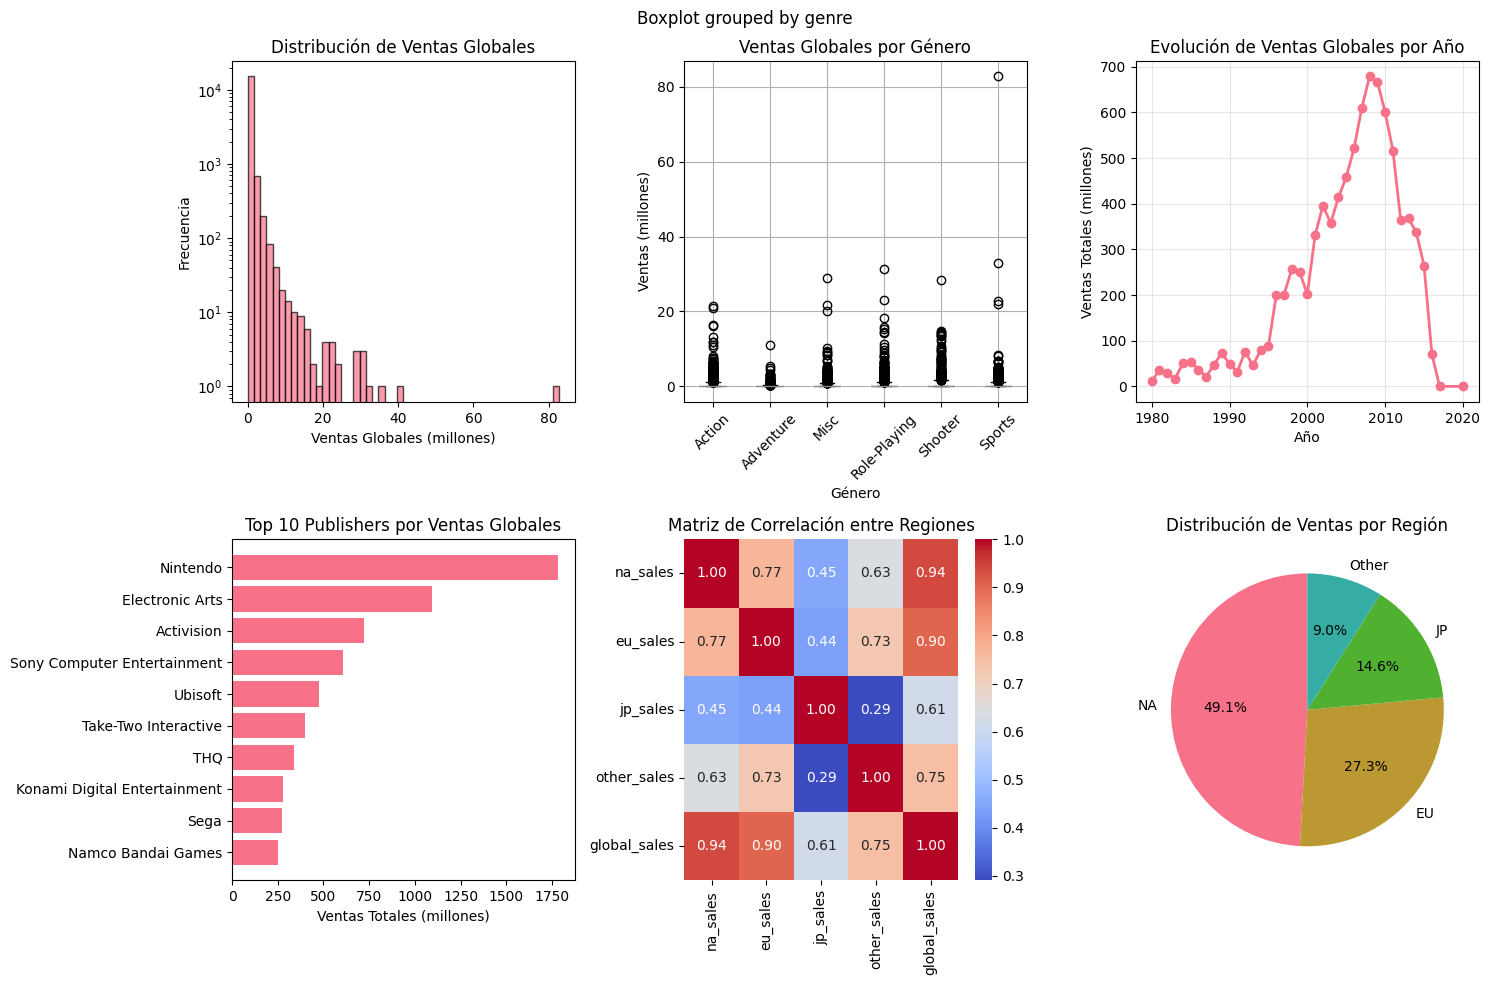

In [ ]:
# Configuración de visualización
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Análisis Exploratorio de Ventas de Videojuegos', fontsize=16)

# 1. Distribución de ventas globales (histograma con log)
axes[0, 0].hist(df['global_sales'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Ventas Globales (millones)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de Ventas Globales')
axes[0, 0].set_yscale('log')

# 2. Boxplot de ventas por género (top 6 géneros)
top_genres = df['genre'].value_counts().head(6).index
df_top_genres = df[df['genre'].isin(top_genres)]
df_top_genres.boxplot(column='global_sales', by='genre', ax=axes[0, 1])
axes[0, 1].set_title('Ventas Globales por Género')
axes[0, 1].set_xlabel('Género')
axes[0, 1].set_ylabel('Ventas (millones)')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Evolución temporal de ventas
ventas_por_año = df.groupby('year')['global_sales'].sum()
axes[0, 2].plot(ventas_por_año.index, ventas_por_año.values, marker='o', linestyle='-', linewidth=2)
axes[0, 2].set_xlabel('Año')
axes[0, 2].set_ylabel('Ventas Totales (millones)')
axes[0, 2].set_title('Evolución de Ventas Globales por Año')
axes[0, 2].grid(True, alpha=0.3)

# 4. Top 10 publishers por ventas
top_publishers = df.groupby('publisher')['global_sales'].sum().sort_values(ascending=False).head(10)
axes[1, 0].barh(range(len(top_publishers)), top_publishers.values)
axes[1, 0].set_yticks(range(len(top_publishers)))
axes[1, 0].set_yticklabels(top_publishers.index)
axes[1, 0].set_xlabel('Ventas Totales (millones)')
axes[1, 0].set_title('Top 10 Publishers por Ventas Globales')
axes[1, 0].invert_yaxis()

# 5. Matriz de correlación (solo métricas)
corr_matrix = df[['na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'global_sales']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('Matriz de Correlación entre Regiones')

# 6. Participación regional
regions = ['na_sales', 'eu_sales', 'jp_sales', 'other_sales']
region_totals = [df[reg].sum() for reg in regions]
axes[1, 2].pie(region_totals, labels=['NA', 'EU', 'JP', 'Other'], autopct='%1.1f%%', startangle=90)
axes[1, 2].set_title('Distribución de Ventas por Región')

plt.tight_layout()
plt.show()

## **2. Limpieza de datos**

In [ ]:
# Registros duplicados
df.duplicated().sum()

np.int64(0)

In [ ]:
# Identificación de outliers en ventas globales usando IQR
Q1 = df['global_sales'].quantile(0.25)
Q3 = df['global_sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['global_sales'] < lower_bound) | (df['global_sales'] > upper_bound)]
print(f"\nAnálisis de Outliers:")
print(f"Límite inferior: {lower_bound:.2f}M")
print(f"Límite superior: {upper_bound:.2f}M")
print(f"Número de outliers detectados: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
print(f"Ventas totales de outliers: {outliers['global_sales'].sum():.2f}M ({outliers['global_sales'].sum()/df['global_sales'].sum()*100:.1f}% del total)")

# Mostrar top 5 outliers
print("\nTop 5 juegos con mayores ventas (potenciales outliers):")
print(df.nlargest(5, 'global_sales')[['name', 'platform', 'genre', 'global_sales']])


Análisis de Outliers:
Límite inferior: -0.57M
Límite superior: 1.11M
Número de outliers detectados: 1826 (11.21%)
Ventas totales de outliers: 5422.52M (61.5% del total)

Top 5 juegos con mayores ventas (potenciales outliers):
                       name platform         genre  global_sales
0                Wii Sports      Wii        Sports         82.74
1         Super Mario Bros.      NES      Platform         40.24
2            Mario Kart Wii      Wii        Racing         35.82
3         Wii Sports Resort      Wii        Sports         33.00
4  Pokemon Red/Pokemon Blue       GB  Role-Playing         31.37


## **3. Tratamiento de valores nulos**

In [ ]:
#Identificar nulos: Paso inicial para comprender la presencia de valores faltantes.
df.isnull().sum()

,0
rank,0
name,0
platform,0
year,0
genre,0
publisher,0
na_sales,0
eu_sales,0
jp_sales,0
other_sales,0


In [ ]:
# Análisis más detallado de valores nulos antes del tratamiento
print("=== ANÁLISIS DE VALORES NULOS ===\n")

# Verificar nulos en año por década
nulos_por_decada = df[df['year'].isna()].shape[0] if df['year'].isna().any() else 0
print(f"Registros con año nulo: {nulos_por_decada}")

# Verificar nulos por publisher
nulos_publisher = df['publisher'].isna().sum()
print(f"Registros con publisher nulo: {nulos_publisher} ({nulos_publisher/len(df)*100:.2f}%)")

# En caso de nulos, mostrar distribución
if df['year'].isna().any():
    print("\nDistribución de juegos con año nulo por plataforma:")
    print(df[df['year'].isna()]['platform'].value_counts().head(10))

# Tratamientos
print("\n Aplicando tratamientos...")
df['year'] = df['year'].fillna(df['year'].median())
df['year'] = df['year'].astype(int)
df['publisher'] = df['publisher'].fillna('Unknown')
print(" Tratamientos completados")

=== ANÁLISIS DE VALORES NULOS ===

Registros con año nulo: 0
Registros con publisher nulo: 0 (0.00%)

 Aplicando tratamientos...
 Tratamientos completados


## **4. Tansformaciones**

In [ ]:
#Crear métricas derivadas
# Total de ventas (validación)
df['total_sales_calc'] = (
    df['na_sales'] +
    df['eu_sales'] +
    df['jp_sales'] +
    df['other_sales']
)

In [ ]:
# Región dominante
df['top_region'] = df[['na_sales','eu_sales','jp_sales','other_sales']].idxmax(axis=1)

In [ ]:
# Década del juego
df['decade'] = (df['year']//10)*10

In [ ]:
# Conversión de tipos
categorical_cols = ['platform','genre','publisher']

for col in categorical_cols:
    df[col] = df[col].astype('category')

In [ ]:
# Métricas adicionales para análisis detallado

# 1. Ventas per cápita (aproximación - asumiendo poblaciones)

print("\n Transformaciones adicionales:")

# 2. Ratio de concentración de mercado (Herfindahl-Hirschman Index - HHI)
# Para medir concentración de publishers
total_ventas = df['global_sales'].sum()
df['publisher_share'] = df.groupby('publisher')['global_sales'].transform('sum') / total_ventas
hhi = (df.groupby('publisher')['global_sales'].sum() / total_ventas * 100).pow(2).sum()
print(f"HHI (Índice de Concentración): {hhi:.2f}")
print("  - HHI < 1500: mercado poco concentrado")
print("  - HHI entre 1500-2500: mercado moderadamente concentrado")
print("  - HHI > 2500: mercado altamente concentrado")

# 3. Éxito por plataforma (ratio de juegos con ventas > 1M)
df['is_hit'] = df['global_sales'] > 1
hit_rate_platform = df.groupby('platform')['is_hit'].mean().sort_values(ascending=False).head(10)
print("\nTop 10 plataformas con mayor tasa de éxito (>1M copias):")
for platform, rate in hit_rate_platform.items():
    print(f"  {platform}: {rate*100:.1f}%")

# 4. Crear variable de éxito categórica
df['success_level'] = pd.cut(df['global_sales'],
                             bins=[0, 0.5, 1, 5, float('inf')],
                             labels=['Bajo', 'Medio', 'Alto', 'Blockbuster'])

print("\n Transformaciones adicionales completadas")


 Transformaciones adicionales:
HHI (Índice de Concentración): 800.90
  - HHI < 1500: mercado poco concentrado
  - HHI entre 1500-2500: mercado moderadamente concentrado
  - HHI > 2500: mercado altamente concentrado

Top 10 plataformas con mayor tasa de éxito (>1M copias):
  NES: 73.5%
  GB: 54.6%
  GEN: 40.7%
  PS4: 21.7%
  XOne: 20.2%
  SNES: 20.1%
  2600: 19.8%
  X360: 18.7%
  PS3: 18.6%
  PS: 16.7%

 Transformaciones adicionales completadas


/tmp/ipykernel_5990/4135343324.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['publisher_share'] = df.groupby('publisher')['global_sales'].transform('sum') / total_ventas
/tmp/ipykernel_5990/4135343324.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hhi = (df.groupby('publisher')['global_sales'].sum() / total_ventas * 100).pow(2).sum()
/tmp/ipykernel_5990/4135343324.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this

## **5. Selección de variables**

In [ ]:
# Dataset final
df.head()

,rank,name,platform,year,genre,publisher,na_sales,eu_sales,jp_sales,other_sales,global_sales,total_sales_calc,top_region,decade,publisher_share,is_hit,success_level
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,82.74,na_sales,2000,0.202501,True,Blockbuster
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,40.24,na_sales,1980,0.202501,True,Blockbuster
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,35.83,na_sales,2000,0.202501,True,Blockbuster
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,33.00,na_sales,2000,0.202501,True,Blockbuster
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,31.38,na_sales,1990,0.202501,True,Blockbuster


In [ ]:
print("\n=== VALIDACIÓN DE CALIDAD DE DATOS ===\n")

# 1. Verificar integridad de ventas
df['diff_sales'] = abs(df['total_sales_calc'] - df['global_sales'])
inconsistent = df[df['diff_sales'] > 0.01]
print(f"1. Consistencia de ventas:")
print(f"   - Registros con diferencia > 0.01M: {len(inconsistent)}")
print(f"   - Diferencia máxima: {df['diff_sales'].max():.4f}M")

# 2. Verificar rangos de años
invalid_years = df[(df['year'] < 1980) | (df['year'] > 2024)]
print(f"\n2. Validación de años:")
print(f"   - Años fuera de rango (1980-2024): {len(invalid_years)}")

# 3. Verificar valores negativos en ventas
negative_sales = df[(df['na_sales'] < 0) | (df['eu_sales'] < 0) |
                    (df['jp_sales'] < 0) | (df['other_sales'] < 0)]
print(f"\n3. Valores negativos en ventas:")
print(f"   - Registros con ventas negativas: {len(negative_sales)}")

# 4. Verificar datos categóricos válidos
valid_genres = ['Action', 'Sports', 'Platform', 'Role-Playing', 'Shooter',
                'Racing', 'Misc', 'Fighting', 'Adventure', 'Simulation',
                'Strategy', 'Puzzle']
invalid_genres = df[~df['genre'].isin(valid_genres)]
print(f"\n4. Validación de géneros:")
print(f"   - Géneros no estándar: {len(invalid_genres)}")
if len(invalid_genres) > 0:
    print(f"   - Valores únicos encontrados: {df['genre'].unique()}")

# 5. Reporte final
print("\n" + "="*50)
print(" VALIDACIÓN COMPLETADA - DATOS LISTOS PARA ANÁLISIS")
print("="*50)
print(f"Total de registros: {len(df):,}")
print(f"Periodo de análisis: {df['year'].min()} - {df['year'].max()}")
print(f"Total ventas globales: {df['global_sales'].sum():.2f}M copias")
print(f"Total publishers únicos: {df['publisher'].nunique()}")
print(f"Total plataformas: {df['platform'].nunique()}")
print(f"Total géneros: {df['genre'].nunique()}")


=== VALIDACIÓN DE CALIDAD DE DATOS ===

1. Consistencia de ventas:
   - Registros con diferencia > 0.01M: 2575
   - Diferencia máxima: 0.0200M

2. Validación de años:
   - Años fuera de rango (1980-2024): 0

3. Valores negativos en ventas:
   - Registros con ventas negativas: 0

4. Validación de géneros:
   - Géneros no estándar: 0

 VALIDACIÓN COMPLETADA - DATOS LISTOS PARA ANÁLISIS
Total de registros: 16,291
Periodo de análisis: 1980 - 2020
Total ventas globales: 8811.97M copias
Total publishers únicos: 576
Total plataformas: 31
Total géneros: 12


## **6. Definir dimensiones y metricas**

In [ ]:
# DIMENSIONES (atributos descriptivos)
dimensiones = [
    'name',
    'platform',
    'genre',
    'publisher',
    'year',
    'decade',
    'top_region'
]

In [ ]:
# Guardar métricas agregadas para análisis rápidos
metricas_resumen = {
    'total_ventas_globales': df['global_sales'].sum(),
    'total_juegos': len(df),
    'venta_promedio': df['global_sales'].mean(),
    'mediana_ventas': df['global_sales'].median(),
    'total_publishers': df['publisher'].nunique(),
    'total_plataformas': df['platform'].nunique(),
    'año_inicio': df['year'].min(),
    'año_fin': df['year'].max(),
    'hhi_concentracion': hhi
}

# Guardar como JSON
import json
with open('metricas_resumen.json', 'w') as f:
    json.dump(metricas_resumen, f, indent=4)

print("\n- Métricas resumen guardadas en 'metricas_resumen.json'")

# Guardar datos agregados por año para análisis temporal
ventas_anuales = df.groupby('year').agg({
    'global_sales': 'sum',
    'na_sales': 'sum',
    'eu_sales': 'sum',
    'jp_sales': 'sum',
    'other_sales': 'sum'
}).reset_index()

ventas_anuales.to_csv('ventas_anuales.csv', index=False)
print("- Datos anuales guardados en 'ventas_anuales.csv'")


- Métricas resumen guardadas en 'metricas_resumen.json'
- Datos anuales guardados en 'ventas_anuales.csv'


## **7. Dataset listo ara analisis**

In [ ]:
df.to_csv("vgsales_clean.csv", index=False)

## **8. Vaidacion final**

In [ ]:
print("Shape final:", df.shape)
df.info()
df.describe()

Shape final: (16291, 18)
<class 'pandas.core.frame.DataFrame'>
Index: 16291 entries, 0 to 16597
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   rank              16291 non-null  int64   
 1   name              16291 non-null  object  
 2   platform          16291 non-null  category
 3   year              16291 non-null  int64   
 4   genre             16291 non-null  category
 5   publisher         16291 non-null  category
 6   na_sales          16291 non-null  float64 
 7   eu_sales          16291 non-null  float64 
 8   jp_sales          16291 non-null  float64 
 9   other_sales       16291 non-null  float64 
 10  global_sales      16291 non-null  float64 
 11  total_sales_calc  16291 non-null  float64 
 12  top_region        16291 non-null  object  
 13  decade            16291 non-null  int64   
 14  publisher_share   16291 non-null  float64 
 15  is_hit            16291 non-null  bool    
 16  su

,rank,year,na_sales,eu_sales,jp_sales,other_sales,global_sales,total_sales_calc,decade,publisher_share,diff_sales
count,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000
mean,8290.190228,2006.405561,0.265647,0.147731,0.078833,0.048426,0.540910,0.540637,2001.814499,0.039703,0.002725
std,4792.654450,5.832412,0.822432,0.509303,0.311879,0.190083,1.567345,1.567460,6.643438,0.049943,0.004466
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,0.000000,1980.000000,0.000001,0.000000
25%,4132.500000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,0.060000,2000.000000,0.001727,0.000000
50%,8292.000000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,0.170000,2000.000000,0.027893,0.000000
75%,12439.500000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.480000,0.480000,2010.000000,0.053738,0.010000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000,82.740000,2020.000000,0.202501,0.020000


# **Fase 4: Definición de KPIs**

# **1. Ventas Globales Totales**
**Justificación**

Este KPI permite medir el tamaño total del mercado. Es clave para entender la magnitud de la industria y evaluar su impacto económico.

**Relación con hipótesis**
*   Relacionado con Hipótesis 1
*   Permite comparar el aporte de los géneros Action y Sports frente a otros

**Interpretación**
*   Un valor alto indica un mercado fuerte y con alta demanda
*   Vemos que esta alto las ventas


In [ ]:
mediana_total = round(df['global_sales'].median(), 2)

mediana_action_sports = round(
    df[df['genre'].isin(['Action', 'Sports'])]['global_sales'].median(), 2
)

mediana_otros = round(
    df[~df['genre'].isin(['Action', 'Sports'])]['global_sales'].median(), 2
)

print("\nKPI 6: Mediana de ventas (millones)")
print(f"Global: {mediana_total}")
print(f"Action/Sports: {mediana_action_sports}")
print(f"Otros: {mediana_otros}")


KPI 6: Mediana de ventas (millones)
Global: 0.17
Action/Sports: 0.21
Otros: 0.15


In [ ]:
kpi_ventas_totales = round(df['global_sales'].sum(), 2)

print(f"Total ventas globales: {kpi_ventas_totales} millones de copias")

KPI 1: Ventas Globales Totales
Total ventas globales: 8811.97 millones de copias


# **2. Participación de mercado por género**
**Justificación**

Permite identificar qué géneros dominan el mercado y hacia dónde dirigir inversiones.

**Relación con hipótesis**

Valida directamente la Hipótesis 1 (Action/Sports dominan)

**Interpretación**

*   Géneros con mayor % = mayor rentabilidad
*   Si Action y Sports lideran → se confirma la hipótesis






In [ ]:
ventas_genero = df.groupby('genre')['global_sales'].sum()
participacion_genero = (ventas_genero / df['global_sales'].sum() * 100).round(2)

top5_generos = participacion_genero.sort_values(ascending=False).head(5)

print("\nKPI 2: Participación de mercado por género (%)")
print(top5_generos )


KPI 2: Participación de mercado por género (%)
genre
Action          19.55
Sports          14.86
Shooter         11.65
Role-Playing    10.48
Platform         9.41
Name: global_sales, dtype: float64


/tmp/ipykernel_18613/166128050.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ventas_genero = df.groupby('genre')['global_sales'].sum()


# **3: Participación regional de ventas**

**Justificación**

Permite definir estrategias de marketing y distribución según la región más rentable.

**Relación con hipótesis**

Valida la Hipótesis 2 (NA domina el mercado).

**Interpretación**

Resultados: NA: 49.1% - EU: 27.3% - JP: 14.6%

Norteamérica domina claramente el mercado, por lo que debe ser el foco principal de lanzamiento y marketing.

In [ ]:
total_global = df['global_sales'].sum()

kpi_na = df['na_sales'].sum() / total_global * 100
kpi_eu = df['eu_sales'].sum() / total_global * 100
kpi_jp = df['jp_sales'].sum() / total_global * 100

print(f"NA: {kpi_na:.1f}%")
print(f"EU: {kpi_eu:.1f}%")
print(f"JP: {kpi_jp:.1f}%")

NA: 49.1%
EU: 27.3%
JP: 14.6%


# **4: Tasa de éxito por plataforma**

**Justificación**

Permite identificar qué plataformas tienen mayor probabilidad de generar juegos exitosos (>1 millón de copias).

**Relación con hipótesis**

Complementa el análisis estratégico del negocio (no directa, pero clave para decisiones).

**Interpretación**

Ejemplo: NES ≈ 73.50% - GB ≈ 54.60%

Las plataformas clásicas muestran alta tasa de éxito, lo que indica menor saturación en su momento o fuerte adopción.

In [ ]:
hit_rate = df.groupby('platform')['is_hit'].mean() * 100
top_plataformas = hit_rate.sort_values(ascending=False).head(5).round(2)

print("\nKPI 4: Tasa de éxito por plataforma (%)")
print(top_plataformas)


KPI 4: Tasa de éxito por plataforma (%)
platform
NES     73.47
GB      54.64
GEN     40.74
PS4     21.73
XOne    20.19
Name: is_hit, dtype: float64


/tmp/ipykernel_18613/121805034.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hit_rate = df.groupby('platform')['is_hit'].mean() * 100


# **5: Índice de concentración del mercado (HHI)**
**Justificación**

Mide si el mercado está dominado por pocos publishers o es competitivo.

**Relación con hipótesis**

Responde a la pregunta de negocio sobre concentración del mercado.

**Interpretación**

Resultado:

HHI: 800.90  "<" 1500 → mercado competitivo

El mercado NO está concentrado, lo que significa que hay oportunidades para nuevos competidores.

In [ ]:
print("\nKPI 5: Índice de concentración (HHI)")
print(f"HHI: {round(hhi, 2)}")


KPI 5: Índice de concentración (HHI)
HHI: 800.9
